In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import prepare_fs_default
from paths import Paths

In [8]:
from paths import Paths

RESULTS_DIR = Paths.RESULTS
DATA_DIR = Paths.DATA
subjects = ['sub-2015052501', 'sub-2015060902', 'sub-2019012101', 'sub-2015060401', 'sub-2015061901', 'sub-2019012402']
corresponding_follow_up = {'sub-2015052501': 'sub-2015120501', 'sub-2015060902': 'sub-2015121001', 'sub-2019012101': 'sub-2019052301', 'sub-2015060401': 'sub-2015120401', 'sub-2015061901': 'sub-2015111402', 'sub-2019012402': 'sub-2019052302'}
pid = subjects[3]
pid_fup = corresponding_follow_up[pid]
pid_id = int(pid.split('-')[1])
pid_fup_id = int(pid_fup.split('-')[1])
PID_RES_DIR = f'{RESULTS_DIR}/{pid}'
PID_FUP_RES_DIR = f'{RESULTS_DIR}/{pid_fup}'

emp_df = pd.read_csv(f'{DATA_DIR}/ALL_daniela_full_extracted_features.csv', index_col = 'pid')
emp_pid_data = emp_df.loc[pid_id]
emp_pid_fup_data = emp_df.loc[pid_fup_id]

sweep_df = pd.read_csv(f'{PID_RES_DIR}/bigger_we_bold_sweep_extracted_features.csv', index_col = 0)
ppc_df = pd.read_csv(f'{PID_RES_DIR}/huifang_ppc_sweep_CORRECT_extracted_features.csv', index_col = 0)
medication_df = pd.read_csv(f'{PID_RES_DIR}/huifang_ppc_sweep_correct_medication_extracted_features.csv', index_col = 0)

In [15]:
pid = 'sub-2015060401'
deriv_dir = f'/Users/giacomopreti/Desktop/VBT/scadv/data/derivatives/{pid}'
results_dir = f'/Users/giacomopreti/Desktop/VBT/scadv/results/{pid}'

In [24]:
def minmaxscale(signal):
    smin = signal.min(axis=0)
    smax = signal.max(axis=0)
    signal = (signal - smin)/(smax - smin)
    return signal

def plot_bold(bold):
    bold = np.array(bold)
    bold = minmaxscale(bold)

    cmap = sns.color_palette("viridis", as_cmap=True)
    purple = cmap(0.1)  # 👈 viridis purple

    plt.figure(figsize=(6,4))
    plt.xlabel('Time (TRs)')
    plt.ylabel('BOLD signal (normalized)')
    plt.plot(range(bold.shape[1]) + 2*bold, linewidth=0.5, color=purple)
    plt.title('Empirical BOLD signal across regions')
    plt.show()

In [25]:
deriv_dir

'/Users/giacomopreti/Desktop/VBT/scadv/data/derivatives/sub-2015060401'

In [26]:
empirical_data = np.load(f'{deriv_dir}/{pid}_ses-baseline_daniela_filtered_bold.npz')
empirical_bold = empirical_data['bold']
empirical_labels = list(empirical_data['labels'])
empirical_tr = empirical_data['TimeRepetition']
# fMRIPrep includes background label (0) but no signal so I remove it
if empirical_labels[0] == 0:
    empirical_labels.pop(0)

assert len(empirical_labels) == empirical_bold.shape[1]
lut = pd.read_csv(
    f"{Paths.RESOURCES}/FreeSurferColorLUT.txt",
    sep=r"\s+",
    comment="#",
    names=["No", "Region", "R", "G", "B", "A"],
    index_col="No",
)

# Load fs_default (target order)
fs = prepare_fs_default()     
fs_regions = fs["Region"].tolist()
# Map fMRIPrep labels to regions
# LUT rows corresponding to fMRIPrep labels
empirical_lut = lut.loc[empirical_labels]
# Build column index mapping, label number to column index in empirical_bold
label_to_col = {label: i for i, label in enumerate(empirical_labels)}

ordered_cols = []
ordered_regions = []

for region in fs_regions:
    rows = empirical_lut[empirical_lut["Region"] == region]

    if len(rows) == 0:
        continue  # region not present in empirical BOLD

    label_no = rows.index[0]              # FreeSurfer label number
    col_idx = label_to_col[label_no]      # column in empirical_bold

    ordered_cols.append(col_idx)
    ordered_regions.append(region)

empirical_bold_to_keep = empirical_bold[4:, ordered_cols]

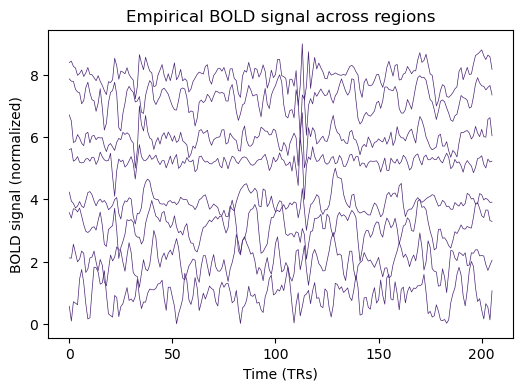

In [27]:
plot_bold(empirical_bold_to_keep[:, :8])

In [8]:
from analysis_utils import compute_features, make_roi_alff_df
bold = empirical_bold_to_keep[:,:, None]
fc, fcd, alff, falff =  compute_features(bold, empirical_tr*1000, window_length=20, overlap=19)

Text(0, 0.5, 'Time Window')

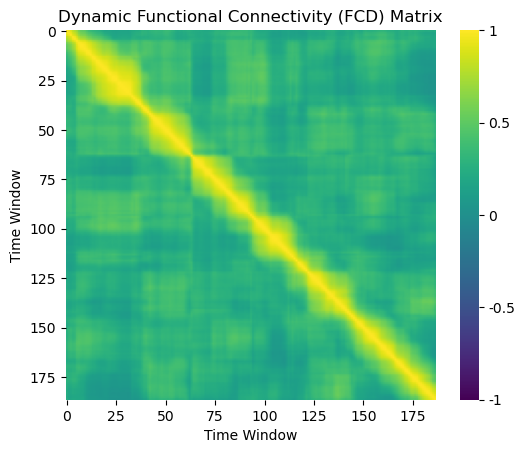

In [9]:
plt.imshow(fcd, vmin=-1, vmax=1, cmap='viridis')
cbar = plt.colorbar()
cbar.outline.set_visible(False)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(['-1', '-0.5', '0', '0.5', '1'])
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
plt.title('Dynamic Functional Connectivity (FCD) Matrix')
plt.xlabel('Time Window')
plt.ylabel('Time Window')

In [12]:
ce_mask = pd.read_csv(f'{Paths.RESOURCES}/Masks/dk_sero_exc_mask.csv', index_col=0)
regions_names = ce_mask.columns.to_list()[:84]
alff_df = make_roi_alff_df(alff, regions_names)

In [15]:
alff_df.to_csv(f'{deriv_dir}/daniela_emp_alff.csv')

In [3]:
def basic_3d_sweep_plot(sweep_df, ppc_df, p1_name, 
    p2_name, p3_name, var_to_plot):
    # Use interactive notebook backend
    from mpl_toolkits.mplot3d import Axes3D
    import matplotlib.pyplot as plt
    #%matplotlib widget

    # Extract coordinates and variable to plot
    x = sweep_df[p1_name].astype(float)
    y = sweep_df[p2_name].astype(float)
    z = sweep_df[p3_name].astype(float)
    c = sweep_df[var_to_plot].astype(float)

    l = ppc_df[p1_name].astype(float)
    m = ppc_df[p2_name].astype(float)
    n = ppc_df[p3_name].astype(float)

    sizes = 1 + (5*(c - c.min()) / (c.max() - c.min()))**4

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(x, y, z, c=c, cmap='viridis', s=sizes, alpha=0.4)
    ax.scatter(l, m, n, c='r', alpha=1)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
    cbar.set_label(var_to_plot)

    ax.set_xlabel(p1_name)
    ax.set_ylabel(p2_name)
    ax.set_zlabel(p3_name)

    plt.title(f'3D Scatter of {var_to_plot}')
    plt.tight_layout()
    plt.show()

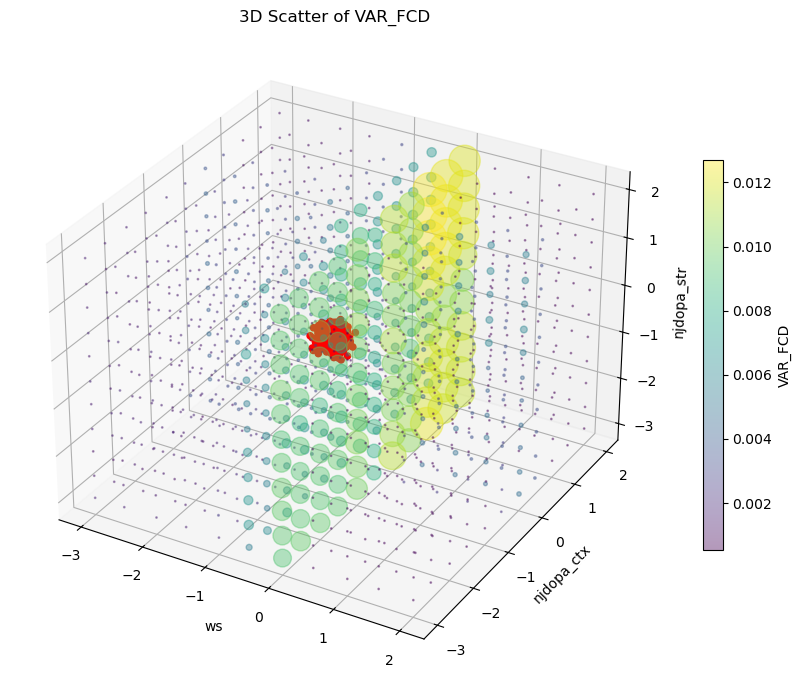

In [7]:
%matplotlib inline
p1_name = 'ws'
p2_name = 'njdopa_ctx'
p3_name = 'njdopa_str'
params = [p1_name, p2_name, p3_name]
sweep_df[params] = np.log10(sweep_df[params])
ppc_df[params] = np.log10(ppc_df[params])
var_to_plot = 'VAR_FCD'
basic_3d_sweep_plot(sweep_df, ppc_df, p1_name, 
    p2_name, p3_name, var_to_plot)

In [11]:
def basic_3d_sweep_plot_with_planes(sweep_df, ppc_df, p1_name, 
                                    p2_name, p3_name, var_to_plot, cmap='viridis'):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.interpolate import griddata

    # ---------------------------------------
    # Extract data
    # ---------------------------------------
    x = sweep_df[p1_name].astype(float).values
    y = sweep_df[p2_name].astype(float).values
    z = sweep_df[p3_name].astype(float).values
    c = sweep_df[var_to_plot].astype(float).values

    l = ppc_df[p1_name].astype(float).values
    m = ppc_df[p2_name].astype(float).values
    n = ppc_df[p3_name].astype(float).values

    # ---------------------------------------
    # Point sizes scaled by variable
    # ---------------------------------------
    if c.max() == c.min():
        sizes = np.ones_like(c) * 10
    else:
        sizes = 1 + (5*(c - c.min()) / (c.max() - c.min()))**4

    # ---------------------------------------
    # Create figure
    # ---------------------------------------
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(x, y, z, c=c, cmap=cmap, s=sizes, alpha=0.5, edgecolors='none')
    ax.scatter(l, m, n, c='r', alpha=1, s=20)

    # ---------------------------------------
    # Interpolation grids for planes
    # ---------------------------------------
    xi = np.linspace(x.min(), x.max(), 40)
    yi = np.linspace(y.min(), y.max(), 40)
    zi = np.linspace(z.min(), z.max(), 40)

    XI, YI = np.meshgrid(xi, yi)
    XI2, ZI = np.meshgrid(xi, zi)
    YI2, ZI2 = np.meshgrid(yi, zi)

    # Interpolate values for contour planes
    C_xy = griddata((x, y), c, (XI, YI), method='linear')
    C_xz = griddata((x, z), c, (XI2, ZI), method='linear')
    C_yz = griddata((y, z), c, (YI2, ZI2), method='linear')

    # ---------------------------------------
    # Add padding
    # ---------------------------------------
    pad = 0.15
    xr, yr, zr = x.max() - x.min(), y.max() - y.min(), z.max() - z.min()
    xmin, xmax = x.min() - pad*xr, x.max() + pad*xr
    ymin, ymax = y.min() - pad*yr, y.max() + pad*yr
    zmin, zmax = z.min() - pad*zr, z.max() + pad*zr
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)

    # ---------------------------------------
    # Contour planes on cube walls
    # ---------------------------------------
    ax.contourf(XI, YI, C_xy, zdir='z', offset=zmin, cmap=cmap, levels=15, alpha=0.3)
    ax.contourf(XI2, C_xz, ZI, zdir='y', offset=ymax, cmap=cmap, levels=15, alpha=0.3)
    ax.contourf(C_yz, YI2, ZI2, zdir='x', offset=xmin, cmap=cmap, levels=15, alpha=0.3)

    # ---------------------------------------
    # Labels and colorbar
    # ---------------------------------------
    ax.set_xlabel(p1_name)
    ax.set_ylabel(p2_name)
    ax.set_zlabel(p3_name)
    ax.set_title(f'3D Scatter of {var_to_plot}')

    cbar = fig.colorbar(sc, shrink=0.6, pad=0.1, label=var_to_plot)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(width=0.5, labelsize=10)

    ax.grid(False)
    plt.tight_layout()
    plt.show()

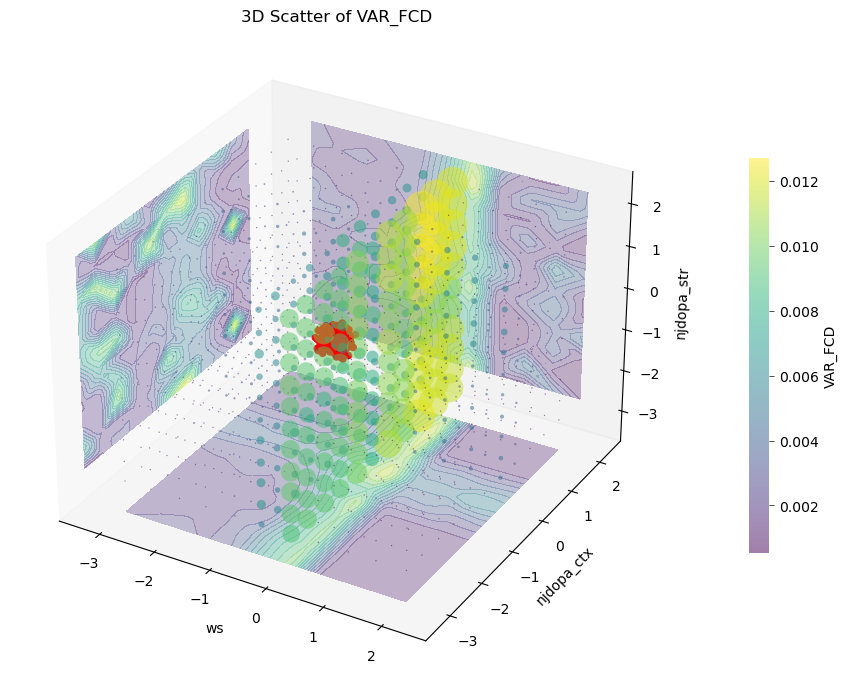

In [12]:
basic_3d_sweep_plot_with_planes(sweep_df, ppc_df, p1_name, 
                                    p2_name, p3_name, var_to_plot, cmap='viridis')

In [34]:
from analysis_utils import drop_high_corr_features
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import numpy as np
#all_synth_df.append(df)

#synth_res_df = pd.concat(all_synth_df, axis=0)
feat_df_reduced = drop_high_corr_features(sweep_df)
params = ['ws', 'njdopa_ctx', 'njdopa_str']
X_train_df = feat_df_reduced.drop(columns=params)

# --- Train ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df.values)

pca = PCA(n_components=2)
X_train_r = pca.fit_transform(X_train_scaled)

# --- Test ---
X_test_scaled = scaler.transform(emp_pid_data[X_train_df.columns].values.reshape(1, -1))
X_test_r = pca.transform(X_test_scaled)


Dropped 16 features


/var/folders/65/0rggzw_s3c39y4m504krlw380000gn/T/ipykernel_18379/2478488185.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap("viridis")


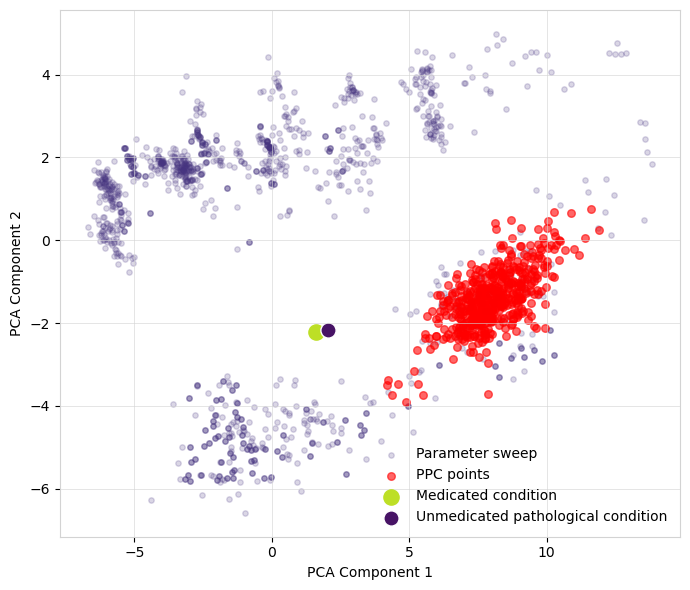

In [39]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# --- PCA components to plot ---
p1_idx = 0  # PCA component 1
p2_idx = 1  # PCA component 2

viridis = cm.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(7,6))

# --- Sweep background points in PCA space ---
ax.scatter(
    X_train_r[:, p1_idx],
    X_train_r[:, p2_idx],
    color=viridis(0.15),   # light color
    alpha=0.2,
    s=15,
    label="Parameter sweep"
)

# --- PPC points in PCA space ---
ppc_scaled = scaler.transform(ppc_df[X_train_df.columns].values)
ppc_r = pca.transform(ppc_scaled)

ax.scatter(
    ppc_r[:, p1_idx],
    ppc_r[:, p2_idx],
    color='r',
    alpha=0.6,
    s=30,
    label="PPC points"
)

# --- Empirical / healthy condition ---
emp_scaled = scaler.transform(emp_pid_fup_data[X_train_df.columns].values.reshape(1,-1))
emp_r = pca.transform(emp_scaled)

ax.scatter(
    emp_r[:, p1_idx],
    emp_r[:, p2_idx],
    color=viridis(0.9),
    s=120,
    label="Medicated condition"
)

# --- Unmedicated condition ---
unmed_scaled = scaler.transform(emp_pid_data[X_train_df.columns].values.reshape(1,-1))
unmed_r = pca.transform(unmed_scaled)

ax.scatter(
    unmed_r[:, p1_idx],
    unmed_r[:, p2_idx],
    color=viridis(0.05),
    s=120,
    edgecolor="white",
    label="Unmedicated pathological condition"
)

# --- Labels ---
ax.set_xlabel(f"PCA Component {p1_idx + 1}")
ax.set_ylabel(f"PCA Component {p2_idx + 1}")

# --- Style ---
ax.grid(True, color="lightgray", linewidth=0.6, alpha=0.7)
for spine in ax.spines.values():
    spine.set_color("lightgray")

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [27]:
medication_df

,GBC,VAR_FCD,Z_D1,Z_D2,Z_S,ws,njdopa_ctx,njdopa_str,med_zi,medication,...,R.HI_ALFF,R.STG_ALFF,R.CER_ALFF,R.CACG_ALFF,R.RACG_ALFF,R.IN_ALFF,R.PCG_ALFF,R.POP_ALFF,R.POR_ALFF,R.PTR_ALFF
0,0.000112,0.000790,0.5000,1.0000,0.2500,0.1502,0.5087,0.2072,0,clozapine,...,-0.254965,0.053104,-0.458332,0.849301,-0.295835,1.821943,0.047744,-0.057008,-0.203212,-0.878243
1,-0.000289,0.000598,0.5000,1.0000,0.2500,0.1678,0.3939,0.3730,0,clozapine,...,0.289101,-0.644876,-1.633087,-0.611743,1.305019,-0.072774,0.708357,-0.818950,0.079353,-1.686784
2,0.019395,0.000433,0.5000,1.0000,0.2500,0.1883,0.5323,0.3062,0,clozapine,...,0.680308,-0.685445,-0.807838,-1.272824,-0.153834,0.809443,0.670934,-0.710782,0.406268,-0.608542
3,0.013614,0.000756,0.5000,1.0000,0.2500,0.1785,0.5309,0.1881,0,clozapine,...,0.948620,-0.176528,1.915102,-0.237332,-0.212966,-0.657742,0.976423,-0.361956,1.111656,1.492732
4,0.006808,0.000661,0.5000,1.0000,0.2500,0.2166,0.3670,0.2552,0,clozapine,...,1.576533,-0.416553,-1.029197,1.606345,-0.357396,0.110485,1.525284,-0.610671,1.667284,-0.523413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.020687,0.000592,0.4919,0.9904,0.1316,0.1709,0.5253,0.2801,9,clozapine,...,0.116179,-0.821299,0.628824,-0.732075,-0.931059,1.513830,0.064412,-0.508044,-0.154777,-0.141763
3996,0.018169,0.000382,0.4919,0.9904,0.1316,0.1537,0.5655,0.2891,9,clozapine,...,-0.043333,-1.173249,0.129340,-0.036205,-0.885976,-0.202201,-0.333501,-0.970670,-0.738706,-0.119551
3997,0.009589,0.000356,0.4919,0.9904,0.1316,0.1914,0.4704,0.3814,9,clozapine,...,-0.534274,-0.937248,-0.546186,0.191359,-0.467501,-0.654219,-0.462268,-0.919142,-0.465044,-0.534696
3998,0.000012,0.000170,0.4919,0.9904,0.1316,0.2392,0.5329,0.4259,9,clozapine,...,0.658874,-0.286502,-0.007025,0.954055,-0.002129,-0.956286,0.248541,0.277384,-0.433379,0.267885



 ========= L.PU-L.CACG ========= 



/var/folders/65/0rggzw_s3c39y4m504krlw380000gn/T/ipykernel_18379/3081419142.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap("viridis")
/var/folders/65/0rggzw_s3c39y4m504krlw380000gn/T/ipykernel_18379/3081419142.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", len(med_types))


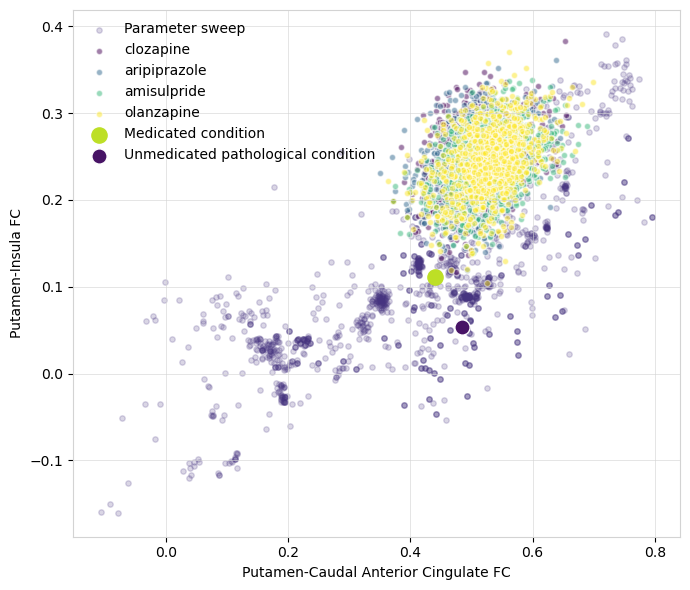


 ========= L.PU-L.RACG ========= 



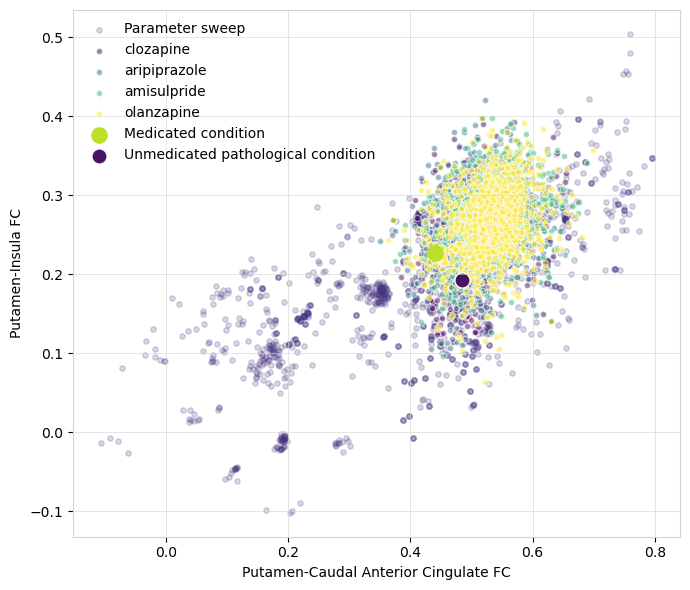


 ========= R.PU-R.CACG ========= 



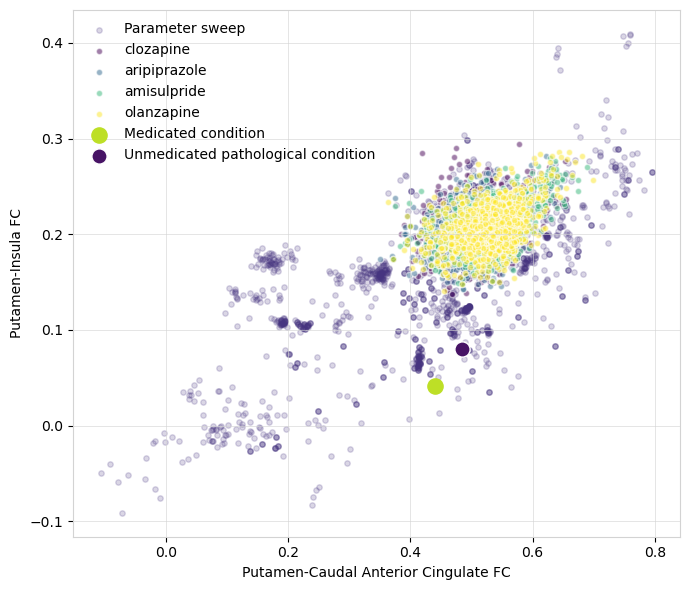


 ========= R.PU-R.RACG ========= 



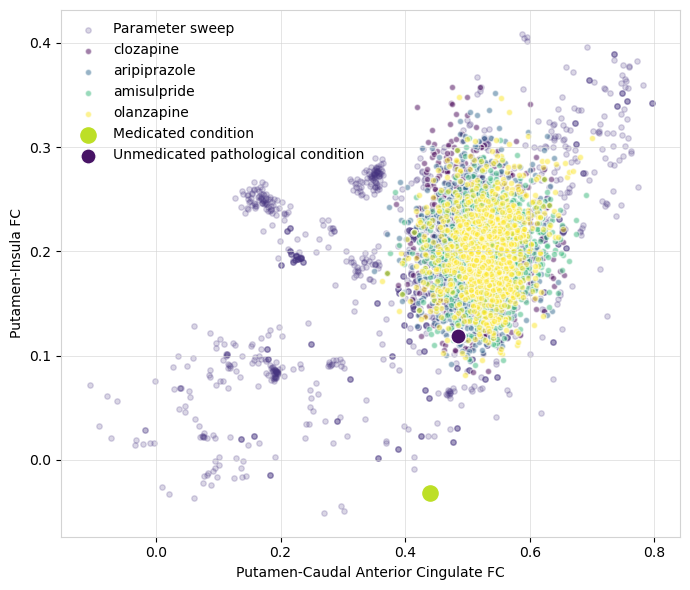


 ========= L.PU-L.IN ========= 



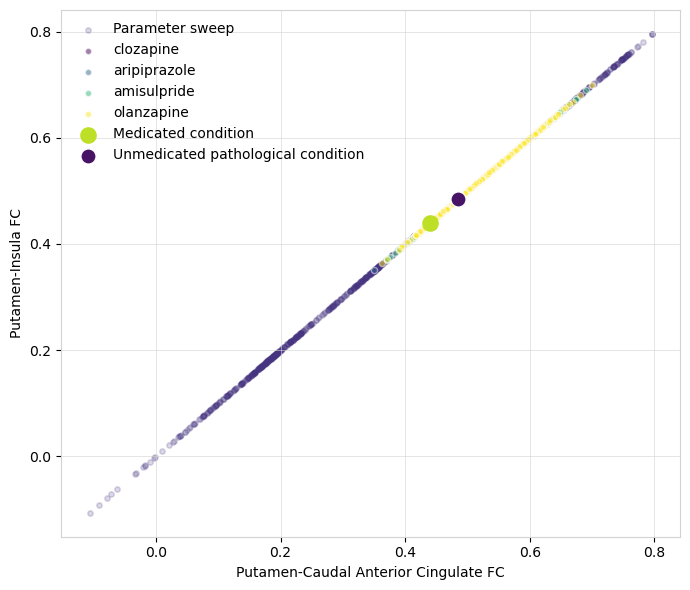


 ========= R.PU-R.IN ========= 



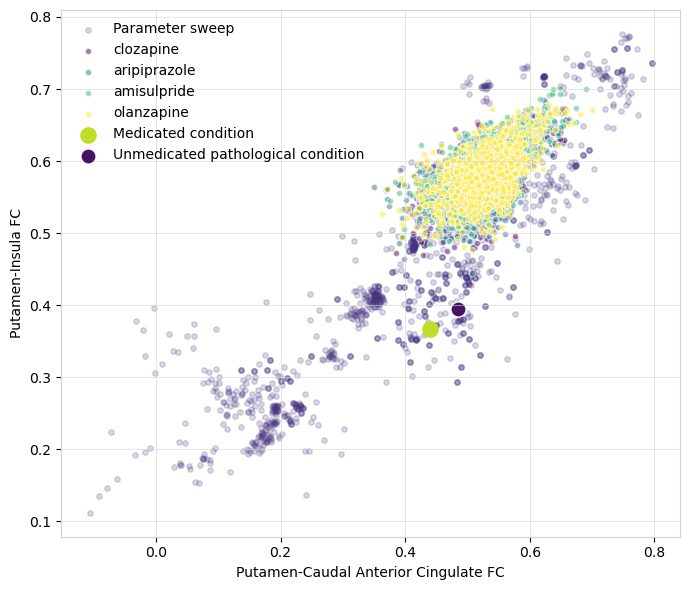


 ========= L.CA-L.HI ========= 



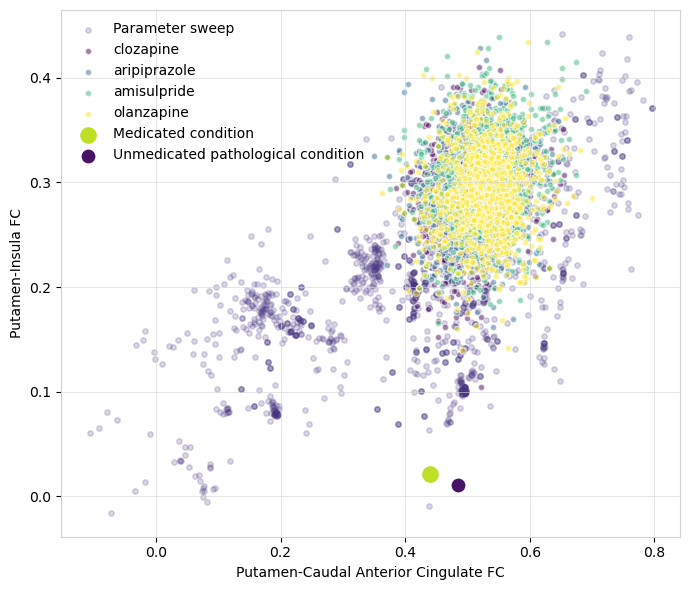


 ========= R.CA-R.HI ========= 



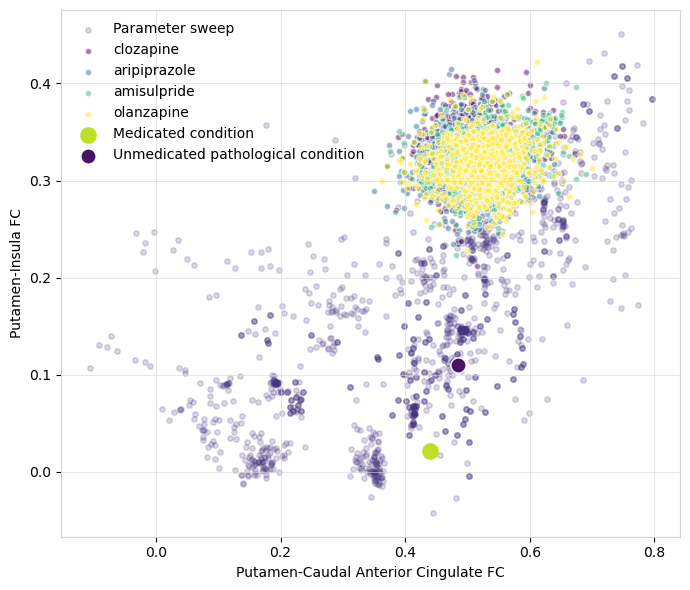


 ========= VAR_FCD ========= 



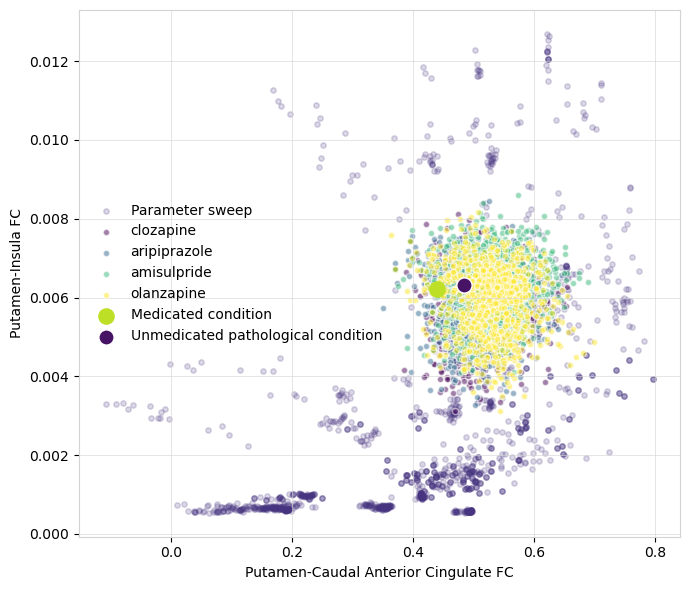

In [55]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

tp = [p for p in medication_df.columns if p not in ['ws', 'njdopa_ctx', 'njdopa_str', 'Z_D1', 'Z_D2','Z_S', 'medication', 'med_zi']]
for p in ['L.PU-L.CACG',
'L.PU-L.RACG',
'R.PU-R.CACG',
'R.PU-R.RACG',
'L.PU-L.IN',
'R.PU-R.IN',
'L.CA-L.HI',
'R.CA-R.HI',
'VAR_FCD']:#['L.PU-L.IN']:#['L.HI-L.IN', 'L.CA-L.CER', 'L.HI_FC', 'VAR_FCD']:
    print(f'\n ========= {p} ========= \n')
    p2 = p#-R.HI'
    p1 = 'L.PU-L.IN'
    #p1 ='GBC'
    #p2 = 'VAR_FCD'

    viridis = cm.get_cmap("viridis")

    fig, ax = plt.subplots(figsize=(7,6))

    # --- Sweep background points ---
    ax.scatter(
        sweep_df[p1],
        sweep_df[p2],
        color=viridis(0.15),   # light blue from viridis
        alpha=0.2,
        s=15,
        label="Parameter sweep"
    )

    #ax.scatter(
    #    ppc_df[p1],
    #    ppc_df[p2],
    #    color='r',   # light blue from viridis
    #    alpha=0.2,
    #    s=15,
    #    label="Parameter sweep"
    #)

    # --- Medicated subjects colored by Z_D2 ---
    med_df = medication_df.copy()

    # Get unique medication types
    med_types = med_df['medication'].unique()

    # Create color map
    cmap = cm.get_cmap("viridis", len(med_types))

    # Loop over medication types
    for i, med in enumerate(med_types):
        sub_df = med_df[med_df['medication'] == med]

        ax.scatter(
            sub_df[p1],
            sub_df[p2],
            color=cmap(i),
            s=20,
            alpha=0.5,
            edgecolor="white",
            label=med
        )

    # --- Healthy condition ---
    ax.scatter(
        emp_pid_fup_data[p1],
        emp_pid_fup_data[p2],
        color=viridis(0.9),   # dark purple
        s=120,
        #edgecolor="white",
        label="Medicated condition"
    )

    # --- Unmedicated condition ---
    ax.scatter(
        emp_pid_data[p1],
        emp_pid_data[p2],
        color=viridis(0.05),   # dark purple
        s=120,
        edgecolor="white",
        label="Unmedicated pathological condition"
    )

    # --- Effective medication (subject 612) ---
    #ax.scatter(
    #    med_df.loc[892, p1],
    #    med_df.loc[892, p2],
    #    s=120,
    #    color=viridis(0.75),   # green from viridis
    #    linewidth=1.5,
    #    label="Aripiprazole"
    #)

    # --- Labels ---
    ax.set_xlabel("Putamen-Caudal Anterior Cingulate FC")
    ax.set_ylabel("Putamen-Insula FC")

    # --- Colorbar for Z_D2 ---
    #cbar = plt.colorbar(sc, ax=ax)
    #cbar.set_label("Z_D2")

    # --- Style ---
    ax.grid(True, color="lightgray", linewidth=0.6, alpha=0.7)
    for spine in ax.spines.values():
        spine.set_color("lightgray")

    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()